In [128]:
# %matplotlib ipympl
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_DUAL, FIGURES_DIR
from nrem_analysis.utils import plot_intervals

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import cmap

import scipy.ndimage
import seaborn as sns

In [129]:
mouse_id        = "107b"
data_dir        = INTERIM_DIR / mouse_id

sleep           = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
session         = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "session.npz")

(<Figure size 1400x250 with 1 Axes>, <Axes: xlabel='Time (s)'>)

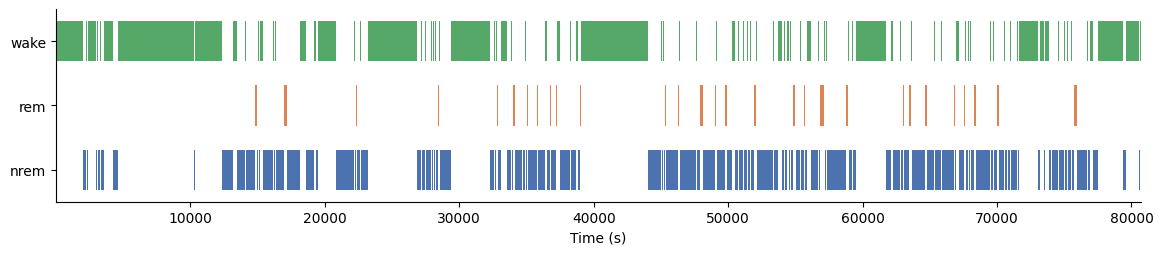

In [10]:
plot_intervals(sleep, 'state')

(<Figure size 1400x250 with 1 Axes>, <Axes: xlabel='Time (s)'>)

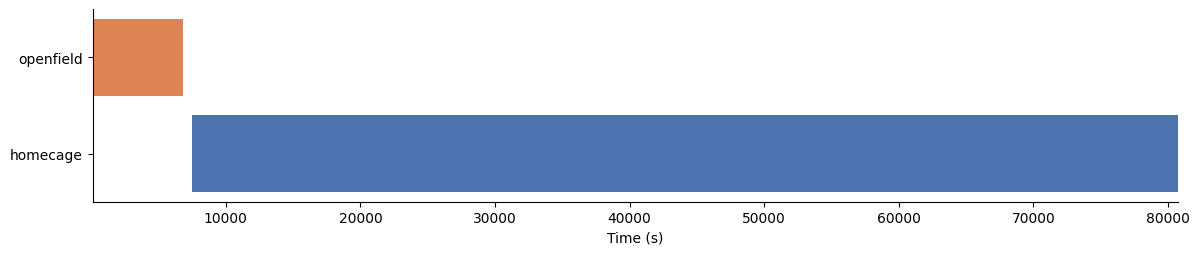

In [14]:
plot_intervals(session, 'state')

In [130]:
wake = sleep[sleep['state'] == 'wake'].intersect(session[session['state'] == 'openfield'])
nrem = sleep[sleep['state'] == 'nrem'].intersect(session[session['state'] == 'homecage'])
rem = sleep[sleep['state'] == 'rem'].intersect(session[session['state'] == 'homecage'])

In [131]:
def detect_pevent(
    units: nap.TsGroup,
    bin_size: float = 0.001,
    smooth_std: float = 0.05,
):
    pv = units.count(bin_size=bin_size).sum(axis=1) / bin_size
    pv = pv.smooth(std=smooth_std)
    thr = pv.mean() + pv.std()
    return pv.threshold(thr).time_support, thr


def plot_raster_and_population_activity(
    spikes: nap.TsGroup,
    unit_ids,
    population_activity: nap.Tsd,
    interval: nap.IntervalSet,
    threshold: float,
    pevents: nap.IntervalSet,
    *,
    figsize=(12, 6),
    activity_ylim=(0, 1050),
):
    t0, t1 = interval.values[0]
    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [2, 3]},
    )

    for row, uid in enumerate(unit_ids, start=1):
        axes[0].eventplot(
            spikes[uid].index,
            lineoffsets=row,
            linelengths=0.6,
            linewidths=1,
            colors="0.15",
        )

    axes[1].plot(population_activity, color="0.05", linewidth=2)
    axes[1].axhline(threshold, color="r", linewidth=0.5)

    shaded_intervals = pevents.intersect(interval)
    for axis in axes:
        axis.spines[["top", "right"]].set_visible(False)
        for start, end in shaded_intervals.values:
            axis.axvspan(start, end, color="0.2", alpha=0.07, zorder=0)

    axes[0].spines["bottom"].set_visible(False)
    axes[0].set_ylabel("Turn cells")
    axes[0].set_ylim(0, len(unit_ids) + 0.5)
    axes[0].set_yticks([0, len(unit_ids)])
    axes[0].set_xlim(t0, t1)

    axes[1].set_ylabel("Summed\nactivity [Hz]")
    axes[1].set_xlabel("Time [s]")
    axes[1].set_ylim(activity_ylim)
    axes[1].xaxis.set_major_formatter(
        FuncFormatter(lambda time, _: f"{time - t0:g}")
    )

    return fig, axes


cw_units = turn_units[turn_units['is_cw']]
order = np.argsort(cw_units['turn_index'].values)
turn_uids = np.array(cw_units.keys())[order]

wake_pevents, wake_thr = detect_pevent(cw_units.restrict(wake))
rem_pevents, rem_thr = detect_pevent(cw_units.restrict(rem))
nrem_pevents, nrem_thr = detect_pevent(cw_units.restrict(nrem))

In [142]:
t0 = 786
t1 = t0 + 12
ep = nap.IntervalSet(start=t0, end=t1)

turn_spikes = cw_units.restrict(ep)
turn_pv = turn_spikes.count(bin_size=0.001).sum(axis=1) / 0.001
turn_pv = turn_pv.smooth(std=0.05)

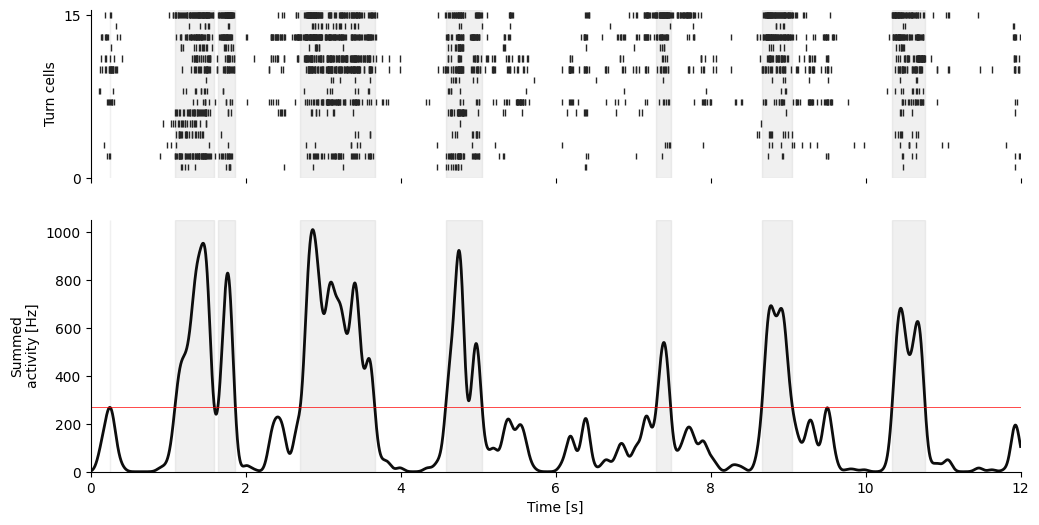

In [143]:
f, ax = plot_raster_and_population_activity(
    turn_spikes,
    turn_uids,
    turn_pv,
    ep,
    wake_thr,
    wake_pevents,
)

plt.savefig(FIGURES_DIR / "snapshots" / "wake_cw.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "snapshots" / "wake_cw.png", format='png', bbox_inches='tight')
plt.show()

In [74]:
t0 = 17100
t1 = t0 + 12
ep = nap.IntervalSet(start=t0, end=t1)

turn_spikes = turn_units.restrict(ep)
turn_pv = turn_spikes.count(bin_size=0.001).sum(axis=1) / 0.001
turn_pv = turn_pv.smooth(std=0.05)

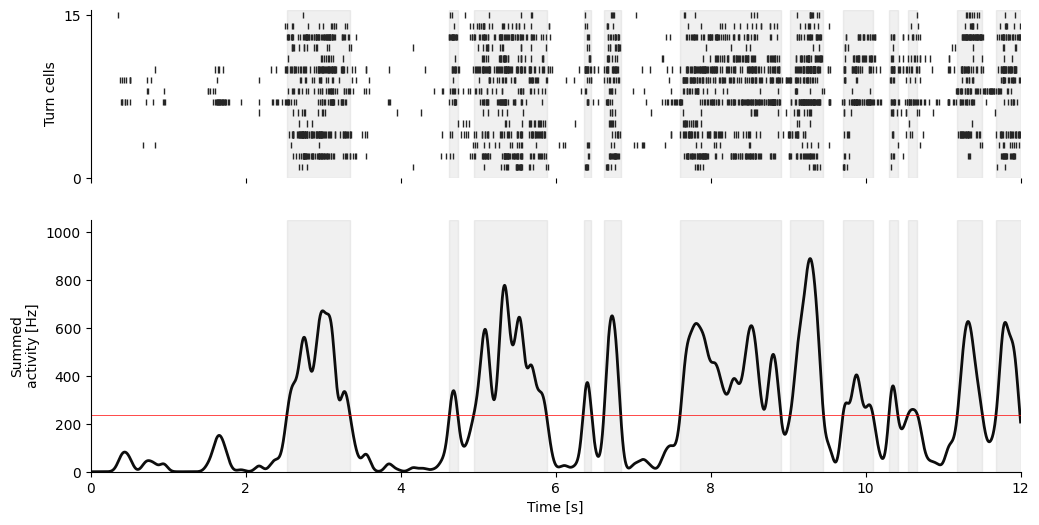

In [77]:
f, ax = plot_raster_and_population_activity(
    turn_spikes,
    turn_uids,
    turn_pv,
    ep,
    rem_thr,
    rem_pevents,
)
plt.show()

In [115]:
nrem

index    start    end
0        10271.0  10373.0
1        10398.0  10427.0
2        12369.0  12548.0
3        12581.0  12984.0
4        12996.0  13029.0
5        13041.0  13138.0
6        13479.0  13666.0
...      ...      ...
289      76749.0  76808.0
290      76824.0  76915.0
291      77144.0  77163.0
292      77172.0  77280.0
293      77309.0  77492.0
294      79391.0  79578.0
295      80587.0  80626.0
shape: (296, 2), time unit: sec.

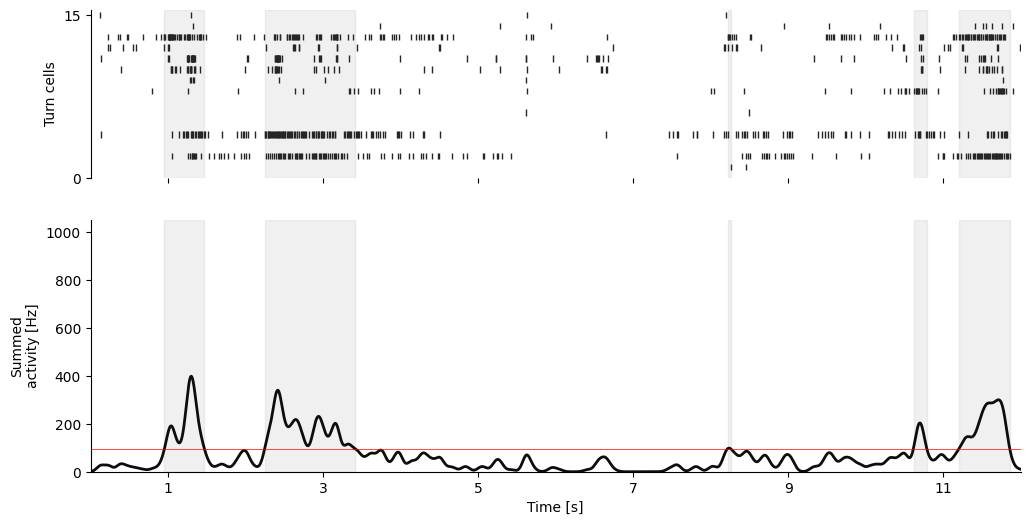

In [137]:
t0 = 35149
t1 = t0 + 12
ep = nap.IntervalSet(start=t0, end=t1)

turn_spikes = turn_units.restrict(ep)
turn_pv = turn_spikes.count(bin_size=0.001).sum(axis=1) / 0.001
turn_pv = turn_pv.smooth(std=0.05)

f, ax = plot_raster_and_population_activity(
    turn_spikes,
    turn_uids,
    turn_pv,
    ep,
    nrem_thr,
    nrem_pevents,
)
plt.show()

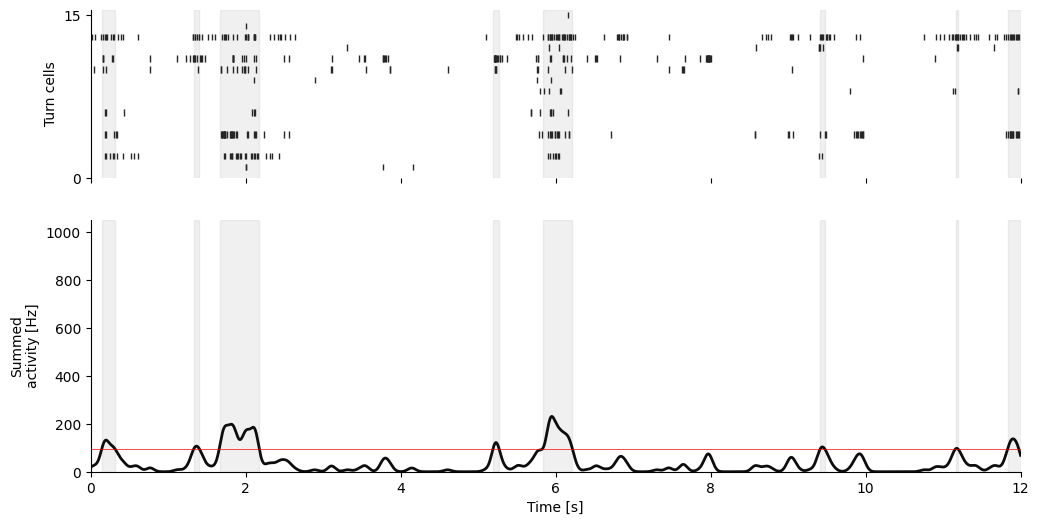

In [136]:
t0 = 35600
t1 = t0 + 12
ep = nap.IntervalSet(start=t0, end=t1)

turn_spikes = turn_units.restrict(ep)
turn_pv = turn_spikes.count(bin_size=0.001).sum(axis=1) / 0.001
turn_pv = turn_pv.smooth(std=0.05)

f, ax = plot_raster_and_population_activity(
    turn_spikes,
    turn_uids,
    turn_pv,
    ep,
    nrem_thr,
    nrem_pevents,
)
plt.show()

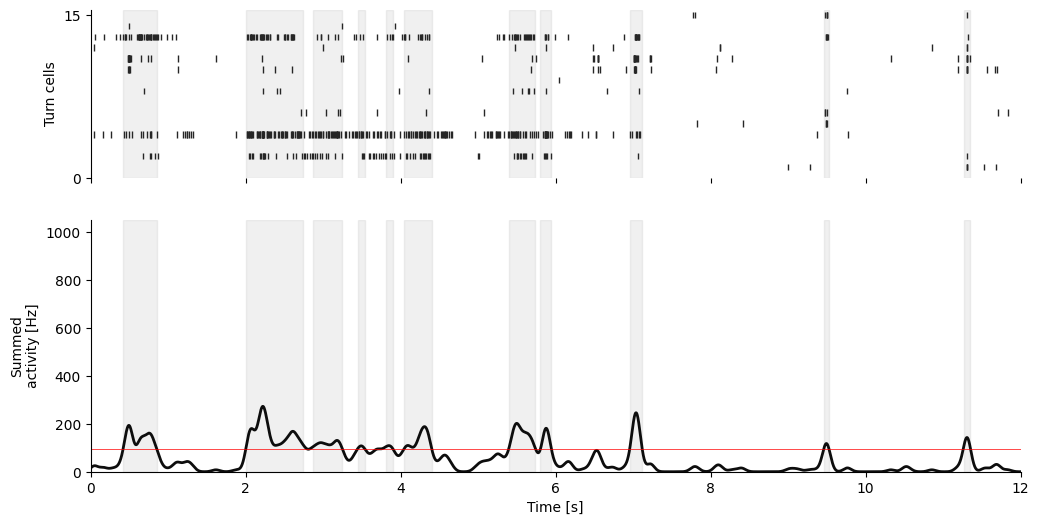

In [135]:
t0 = 35664
t1 = t0 + 12
ep = nap.IntervalSet(start=t0, end=t1)

turn_spikes = turn_units.restrict(ep)
turn_pv = turn_spikes.count(bin_size=0.001).sum(axis=1) / 0.001
turn_pv = turn_pv.smooth(std=0.05)

f, ax = plot_raster_and_population_activity(
    turn_spikes,
    turn_uids,
    turn_pv,
    ep,
    nrem_thr,
    nrem_pevents,
)
plt.show()

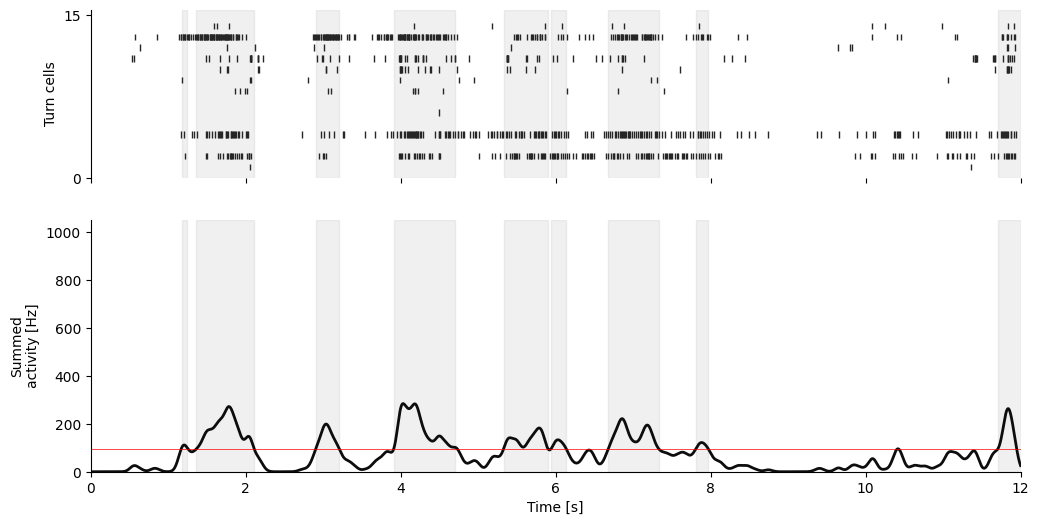

In [134]:
t0 = 35738
t1 = t0 + 12
ep = nap.IntervalSet(start=t0, end=t1)

turn_spikes = turn_units.restrict(ep)
turn_pv = turn_spikes.count(bin_size=0.001).sum(axis=1) / 0.001
turn_pv = turn_pv.smooth(std=0.05)

f, ax = plot_raster_and_population_activity(
    turn_spikes,
    turn_uids,
    turn_pv,
    ep,
    nrem_thr,
    nrem_pevents,
)
plt.show()

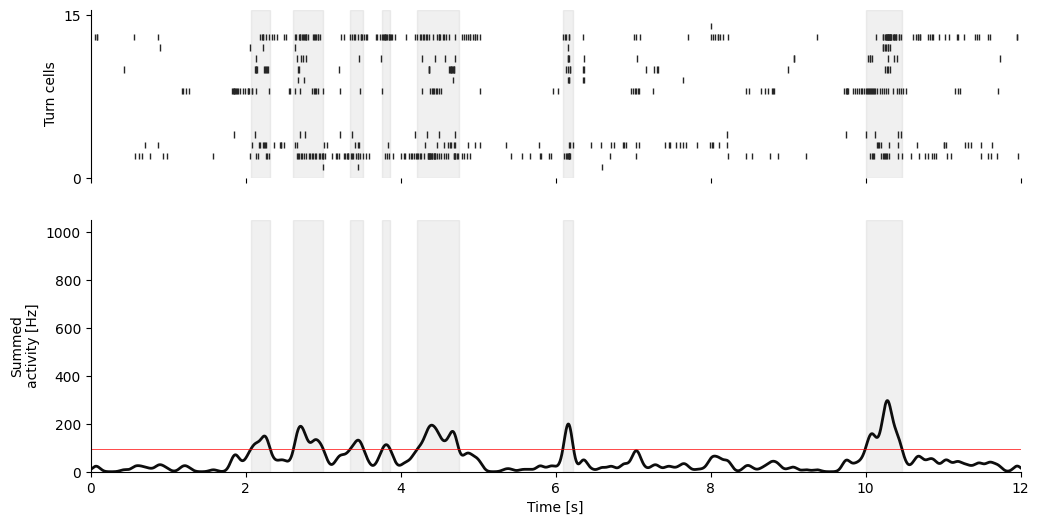

In [144]:
t0 = 47798
t1 = t0 + 12
ep = nap.IntervalSet(start=t0, end=t1)

turn_spikes = turn_units.restrict(ep)
turn_pv = turn_spikes.count(bin_size=0.001).sum(axis=1) / 0.001
turn_pv = turn_pv.smooth(std=0.05)

f, ax = plot_raster_and_population_activity(
    turn_spikes,
    turn_uids,
    turn_pv,
    ep,
    nrem_thr,
    nrem_pevents,
)

plt.savefig(FIGURES_DIR / "snapshots" / "nrem_cw.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "snapshots" / "nrem_cw.png", format='png', bbox_inches='tight')
plt.show()